In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
from pathlib import Path
from scipy.interpolate import make_smoothing_spline


# from collections import defaultdict

# from tqdm import tqdm
# # from scipy.interpolate import BSpline
# from joblib import Parallel, delayed



# Load data

In [9]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'


In [10]:
median_fn = metabolomics_folder / 'G_median_z_scores_TIC_norm_keio.csv'
df_data = pd.read_csv(median_fn)
df_data.rename(columns={'Z-score median': 'Median Z-score'}, inplace=True)

ionMz_annotation_fn = metabolomics_folder / 'H_ionMz_annotation.csv'
df_ionMz = pd.read_csv(ionMz_annotation_fn, index_col=0)

sample_metadata_fn = metabolomics_folder / 'I_sample_metadata_keio.csv'
df_sample_metadata = pd.read_csv(sample_metadata_fn, index_col=0)

In [11]:
df_w_mz = df_data.merge(df_ionMz, on='ionMz', how='left')

In [12]:
df = df_w_mz.merge(df_sample_metadata, on=['Batch-Tube', 'Timepoint'], how='left')

In [13]:
df['Batch-Tube and Timepoint'] = df['Batch-Tube'] + '_' + df['Timepoint'].astype(str)


# Compute AUC Z-score for all tubes for all metabolites

In [6]:
df.sort_values(by=['Batch-Tube', 'ionMz', 'Hours'], inplace=True)

In [7]:
all_mz = df['ionMz'].unique()
auc_data = []
lam = 1
for bt in df['Batch-Tube'].unique():
    df_bt = df[df['Batch-Tube'] == bt]
    for mz in all_mz:
        df_mz = df_bt[df_bt['ionMz'] == mz]
        if len(df_mz) < 2:
            continue
        
        auc_data_i = [bt, mz, df_mz['Strain'].values[0]]
        for xaxis in ['AUC OD', 'Hours']:
            x = df_mz[xaxis].values
            y = df_mz['Median Z-score'].values
            w = 1/df_mz['Z-score std']
            if len(x) != len(np.unique(x)):
                # Add tiny noise to avoid duplicate values
                x = x+np.sort(1e-3*np.random.randn(len(x)))
            spline  =  make_smoothing_spline(x, y, w = w, lam =lam)
            xarr = np.linspace(min(x), max(x), 100)
            fit_zscore = spline(xarr)
            # y = fit_zscore - fit_zscore[0]
            # plt.plot(xarr, y, color='green')
            auc_zscore = np.trapezoid(fit_zscore, dx=xarr[1]-xarr[0])
            auc_data_i += [auc_zscore, fit_zscore[0],fit_zscore[-1], np.min(fit_zscore), np.max(fit_zscore)]
        
        # plt.plot(df_mz['AUC OD'], df_mz['Median Z-score'], marker='o')
        # plt.plot(df_mz['AUC OD'], spline1(df_mz['AUC OD']), color='red')
        auc_data.append(auc_data_i)
        # plt.show()
        
    

In [8]:
auc_df = pd.DataFrame(auc_data, columns=['Batch-Tube', 'ionMz', 'Strain', 'AUC Z-score (AUC OD)', 'Z-score start (AUC OD)', 'Z-score end (AUC OD)', 'Z-score min (AUC OD)', 'Z-score max (AUC OD)', 'AUC Z-score (Hours)', 'Z-score start (Hours)', 'Z-score end (Hours)', 'Z-score min (Hours)', 'Z-score max (Hours)'])
auc_df.to_csv(metabolomics_folder / 'J_auc_z_scores_keio.csv', index=False)

In [9]:
auc_df['Batch'] = [x[0] for x in auc_df['Batch-Tube'].str.split('-')]

In [10]:
auc_average = auc_df.groupby(['Strain', 'ionMz', 'Batch']).agg({'AUC Z-score (AUC OD)':('mean', 'std')}).reset_index()
auc_average.columns = ['Strain', 'ionMz','Batch', 'Mean', 'Std']
auc_average.sort_values(by = 'Std', ascending = False, inplace = True)

In [11]:
auc_average.head(40)

,Strain,ionMz,Batch,Mean,Std
14754,tdcC,191.0196,4,39.862324,34.935079
582,WT,173.0932,4,24.870744,24.501047
6899,glpT,190.0558,5,12.513282,23.734718
725,WT,194.0686,4,9.481908,21.691449
587,WT,173.1041,4,19.788678,21.582997
5955,gadC,289.1043,3,24.125908,21.530845
5897,gadC,189.0880,3,24.792920,21.279255
14731,tdcC,173.0932,4,15.945109,21.269705
14689,tdcC,145.0986,4,32.470746,20.547281
5812,gadC,128.0719,3,23.608032,19.809782


Strain         tdcC
ionMz      191.0196
Batch             4
Mean      39.862324
Std       34.935079
Name: 14754, dtype: object


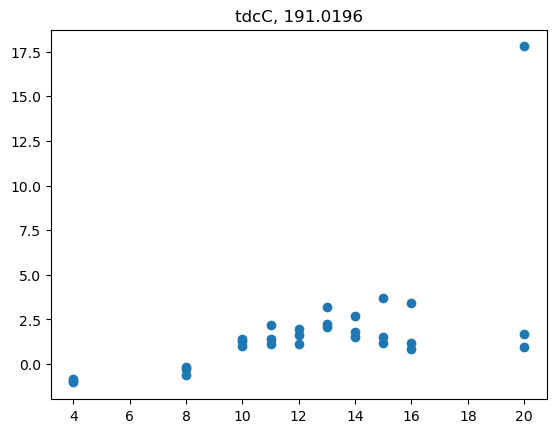

Strain           WT
ionMz      173.0932
Batch             4
Mean      24.870744
Std       24.501047
Name: 582, dtype: object


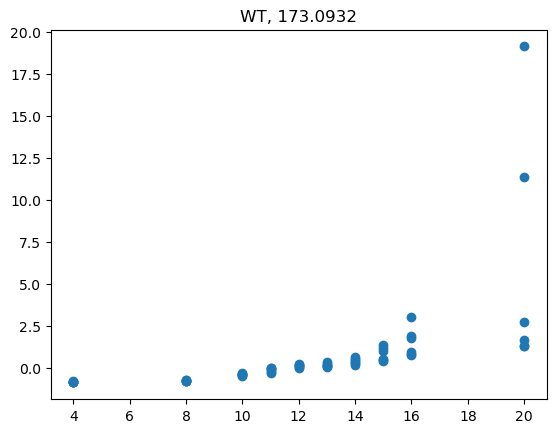

In [12]:
j = 0
for i, row in auc_average.iterrows():
    print(row)
    idx = (df.Strain==row['Strain'])&(df.ionMz==row['ionMz'])&(df.Batch==int(row['Batch']))
    plt.scatter(df.loc[idx, 'Hours'], df.loc[idx, 'Median Z-score'])
    plt.title(f'{row['Strain']}, {row['ionMz']}')
    plt.show()
    j+=1
    if j> 1:
        break

In [13]:
auc_average

,Strain,ionMz,Batch,Mean,Std
14754,tdcC,191.0196,4,39.862324,34.935079
582,WT,173.0932,4,24.870744,24.501047
6899,glpT,190.0558,5,12.513282,23.734718
725,WT,194.0686,4,9.481908,21.691449
587,WT,173.1041,4,19.788678,21.582997
...,...,...,...,...,...
5396,focA,180.0664,3,-6.261381,0.012205
12046,ptsG,237.0611,2,-3.495161,0.011347
2743,aroP,341.1089,2,-10.531378,0.006136
11932,ptsG,131.0350,2,1.347062,0.003835


# Other strains

In [14]:
median_fn = metabolomics_folder / 'G_median_z_scores_TIC_norm_others.csv'
df_data = pd.read_csv(median_fn)
df_data.rename(columns={'Z-score median': 'Median Z-score'}, inplace=True)

ionMz_annotation_fn = metabolomics_folder / 'H_ionMz_annotation.csv'
df_ionMz = pd.read_csv(ionMz_annotation_fn, index_col=0)

sample_metadata_fn = metabolomics_folder / 'I_sample_metadata_others.csv'
df_sample_metadata = pd.read_csv(sample_metadata_fn, index_col=0)

In [15]:
df_w_mz = df_data.merge(df_ionMz, on='ionMz', how='left')

In [16]:
df = df_w_mz.merge(df_sample_metadata, on=['Batch-Tube', 'Timepoint'], how='left')

# Compute AUC Z-score for all tubes for all metabolites

In [17]:
df.sort_values(by=['Batch-Tube', 'ionMz', 'Hours'], inplace=True)

In [18]:
all_mz = df['ionMz'].unique()
auc_data = []
lam = 1
for bt in df['Batch-Tube'].unique():
    df_bt = df[df['Batch-Tube'] == bt]
    for mz in all_mz:
        df_mz = df_bt[df_bt['ionMz'] == mz]
        if len(df_mz) < 2:
            continue
        
        auc_data_i = [bt, mz, df_mz['Strain'].values[0]]
        for xaxis in ['AUC OD', 'Hours']:
            x = df_mz[xaxis].values
            y = df_mz['Median Z-score'].values
            w = 1/df_mz['Z-score std']
            if len(x) != len(np.unique(x)):
                # Add tiny noise to avoid duplicate values
                x = x+np.sort(1e-3*np.random.randn(len(x)))
            spline  =  make_smoothing_spline(x, y, w = w, lam =lam)
            xarr = np.linspace(min(x), max(x), 100)
            fit_zscore = spline(xarr)
            # y = fit_zscore - fit_zscore[0]
            # plt.plot(xarr, y, color='green')
            auc_zscore = np.trapezoid(fit_zscore, dx=xarr[1]-xarr[0])
            auc_data_i += [auc_zscore, fit_zscore[0],fit_zscore[-1], np.min(fit_zscore), np.max(fit_zscore)]
        
        # plt.plot(df_mz['AUC OD'], df_mz['Median Z-score'], marker='o')
        # plt.plot(df_mz['AUC OD'], spline1(df_mz['AUC OD']), color='red')
        auc_data.append(auc_data_i)
        # plt.show()
        
    

In [19]:
auc_df.sort_values(by=['Batch-Tube', 'ionMz'], inplace=True)

In [20]:
auc_df = pd.DataFrame(auc_data, columns=['Batch-Tube', 'ionMz', 'Strain', 'AUC Z-score (AUC OD)', 'Z-score start (AUC OD)', 'Z-score end (AUC OD)', 'Z-score min (AUC OD)', 'Z-score max (AUC OD)', 'AUC Z-score (Hours)', 'Z-score start (Hours)', 'Z-score end (Hours)', 'Z-score min (Hours)', 'Z-score max (Hours)'])
auc_df.to_csv(metabolomics_folder / 'J_auc_z_scores_others.csv', index=False)